# 06 — Sexto estudio: grilla de escenarios

Este notebook ejecuta la grilla de escenarios del sexto estudio y selecciona el tamaño de bloque `b` con ratio CBB promedio más cercano a 1.

In [1]:
# Ejecutar una vez si aparece ModuleNotFoundError
from pathlib import Path
import sys, subprocess
cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent, cwd.parent.parent]
ROOT = None
for path in candidates:
    if (path / "pyproject.toml").exists() and (path / "src" / "codispersion_bootstrap").exists():
        ROOT = path
        break
if ROOT is None:
    raise RuntimeError(f"No encontré la carpeta raíz del proyecto. Estoy parado en: {cwd}")
print("Carpeta raíz encontrada:", ROOT)
subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", str(ROOT)])
print("Paquete instalado correctamente. Reinicia el kernel después de esta celda si es primera vez.")

Carpeta raíz encontrada: C:\ONEDRIVECOPIA\OneDrive - Universidad Técnica Federico Santa María\Escritorio\Memoria\Documentos Necesarios\codispersion_github_template
Paquete instalado correctamente. Reinicia el kernel después de esta celda si es primera vez.


In [1]:
from codispersion_bootstrap import run_grid_study, select_best_b
from codispersion_bootstrap.plotting import plot_variance_ratio, plot_coverage

## Test

In [2]:
H = [(1,0), (0,1), (1,1), (-1,1), (2,0), (0,2), (2,2), (-2,2)]
df_test = run_grid_study(
    n1=64,
    n2=64,
    nu=1.0,
    range_pix_list=[1.5, 3.5],
    rho0_list=[0.2, 0.5],
    anis_mode_list=["iso", "aniso"],
    b_list=[8, 12],
    H=H,
    B_boot=30,
    R_mc=8,
    seed_base=2025,
)
df_test.head()
df_test

,h,h1,h2,rho_hat_mean,Var_MC,Var*_BB_mean,ratio_BB,coverage_BB,Var*_CBB_mean,ratio_CBB,coverage_CBB,range_pix,rho0,anis_mode,b,B_boot,R_mc,nu
0,"(1, 0)",1,0,0.209064,0.000798,0.000712,0.892235,0.750,0.000746,0.935571,0.750,1.5,0.2,iso,8,30,8,1.0
1,"(0, 1)",0,1,0.192146,0.000442,0.000839,1.896510,1.000,0.000750,1.696573,0.875,1.5,0.2,iso,8,30,8,1.0
2,"(1, 1)",1,1,0.200282,0.000757,0.000741,0.979344,0.750,0.000859,1.134100,0.875,1.5,0.2,iso,8,30,8,1.0
3,"(-1, 1)",-1,1,0.201076,0.000656,0.000765,1.166643,0.750,0.000719,1.096195,0.750,1.5,0.2,iso,8,30,8,1.0
4,"(2, 0)",2,0,0.208695,0.001372,0.000912,0.664777,0.750,0.001015,0.739926,0.750,1.5,0.2,iso,8,30,8,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,"(-1, 1)",-1,1,0.507442,0.001208,0.001829,1.514516,0.750,0.001776,1.470969,0.625,3.5,0.5,aniso,12,30,8,1.0
124,"(2, 0)",2,0,0.506254,0.001142,0.001126,0.986197,0.875,0.001392,1.219304,0.875,3.5,0.5,aniso,12,30,8,1.0
125,"(0, 2)",0,2,0.512114,0.001129,0.001301,1.152056,0.875,0.001517,1.343624,0.875,3.5,0.5,aniso,12,30,8,1.0
126,"(2, 2)",2,2,0.513768,0.003100,0.001685,0.543571,0.625,0.001977,0.637638,1.000,3.5,0.5,aniso,12,30,8,1.0


In [3]:
best_b = select_best_b(df_test)
best_b

,range_pix,rho0,anis_mode,b,ratio_mean,score_abs_ratio_minus_1
0,1.5,0.2,aniso,12,0.854248,0.145752
1,1.5,0.2,iso,8,1.026851,0.026851
2,1.5,0.5,aniso,12,1.280715,0.280715
3,1.5,0.5,iso,12,1.303536,0.303536
4,3.5,0.2,aniso,12,1.856831,0.856831
5,3.5,0.2,iso,8,1.007298,0.007298
6,3.5,0.5,aniso,12,1.312768,0.312768
7,3.5,0.5,iso,12,1.051231,0.051231


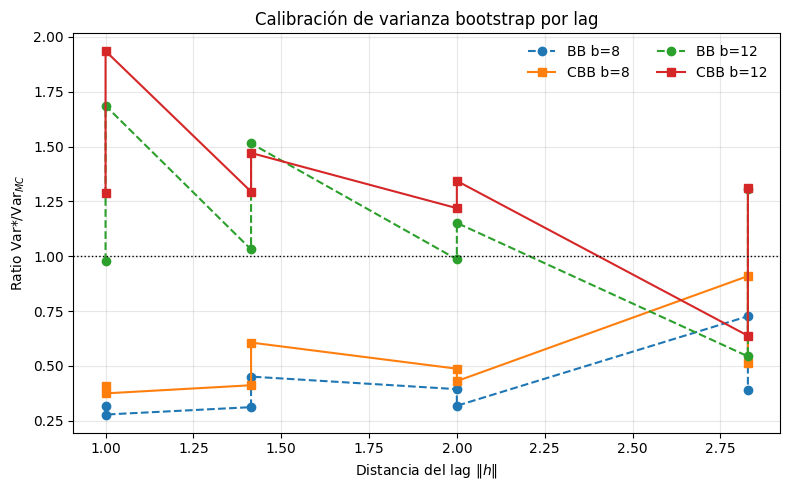

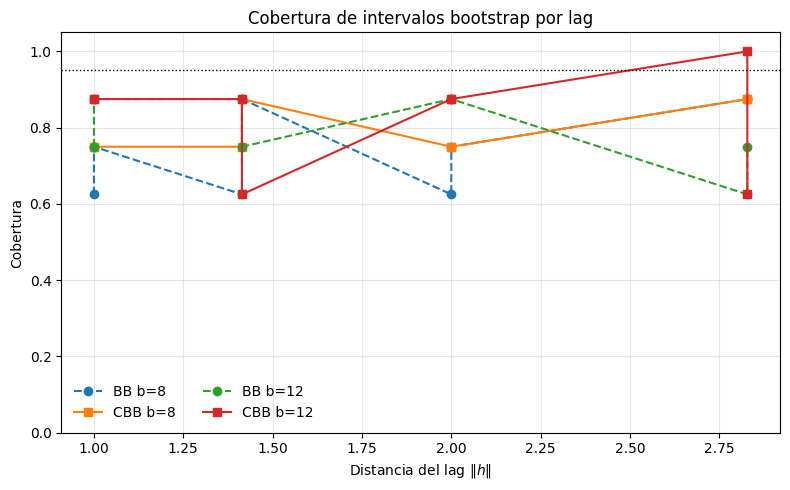

In [4]:
# Ejemplo: graficar solo un escenario para no mezclar demasiadas curvas
sub = df_test[(df_test["rho0"] == 0.5) & (df_test["range_pix"] == 3.5) & (df_test["anis_mode"] == "aniso")]
plot_variance_ratio(sub)
plot_coverage(sub);

## Simulación

In [ ]:
from codispersion_bootstrap import run_grid_study

H = [
    (1,0), (0,1), (1,1), (-1,1),
    (2,0), (0,2), (2,2), (-2,2),
]

df_full = run_grid_study(
    n1=256,
    n2=256,
    nu=1.0,
    range_pix_list=[1.5, 3.5, 6.0],
    rho0_list=[0.2, 0.5, 0.8],
    anis_mode_list=["iso", "aniso"],
    b_list=[4, 8, 16, 32, 48, 52, 64],
    H=H,
    B_boot=800,
    R_mc=100,
    anis_ratio=2.0,
    angle_deg=45.0,
    use_taper=True,
    tukey_alpha=0.5,
    seed_base=2025,
)

In [ ]:
df_full.to_csv("../results/sexto_estudio_grid_quick.csv", index=False)
best_b.to_csv("../results/sexto_estudio_best_b_quick.csv", index=False)

In [ ]:
best_b = select_best_b(df_test)
best_b

In [ ]:
from codispersion_bootstrap import generate_all_sexto_figures

plot_out = generate_all_sexto_figures(
    df_full,
    outdir="../results/graficas_codispersion_full",
    summary_csv_path="../results/escenarios_codispersion_resumen_126_reconstruido.csv",
    best_blocks_csv_path="../results/sexto_estudio_bloques_optimos.csv",
    show=False,
    curve_degree=2,
)

plot_out["df_summary"].head()

In [ ]:
from codispersion_bootstrap import generate_coverage_ratio_polynomial_fits

fit_out = generate_coverage_ratio_polynomial_fits(
    plot_out["df_summary"],
    outdir="../results/graficas_codispersion_full",
    degree=2,
    show=True,
)

fit_out

In [ ]:
for method, fit in fit_out["fits_by_method"].items():
    print("\n" + "=" * 70)
    print(f"Método: {method}")
    print("=" * 70)

    coef = fit["coef"]
    r2 = fit["r2"]

    a, b, c = coef
    xv, yv = fit["vertex"]

    print(f"Ajuste: Cobertura = ({a:.6f}) x^2 + ({b:.6f}) x + ({c:.6f})")
    print(f"R^2 = {r2:.4f}")
    print(f"Vértice: x* = {xv:.4f}, Cobertura(x*) = {yv:.4f}")

print("\n" + "=" * 70)
print("Ajuste global")
print("=" * 70)

coef = fit_out["fit_global"]["coef"]
r2 = fit_out["fit_global"]["r2"]
xv, yv = fit_out["fit_global"]["vertex"]

a, b, c = coef

print(f"Ajuste: Cobertura = ({a:.6f}) x^2 + ({b:.6f}) x + ({c:.6f})")
print(f"R^2 = {r2:.4f}")
print(f"Vértice: x* = {xv:.4f}, Cobertura(x*) = {yv:.4f}")